# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Classification

## Load Data

In [65]:
df = pd.read_csv('./drug200.csv') # read in the csv file
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


## Data Exploration

In [66]:
df.isnull().sum() # check for missing values

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [67]:
df.info() # check the data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [68]:
df.describe() # check the summary statistics

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [69]:
# check the unique values in each categorical features
for col in df.columns :
    if df[col].dtype == 'object' :
        print(col, df[col].unique())

Sex ['F' 'M']
BP ['HIGH' 'LOW' 'NORMAL']
Cholesterol ['HIGH' 'NORMAL']
Drug ['DrugY' 'drugC' 'drugX' 'drugA' 'drugB']


<Axes: xlabel='Age', ylabel='Count'>

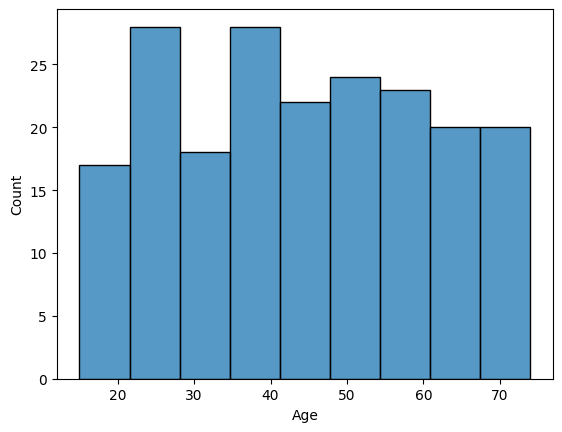

In [70]:
sns.histplot(df['Age']) # check the distribution of Age, is it normal?

Age feature is not normally distributed.

<Axes: xlabel='Na_to_K', ylabel='Count'>

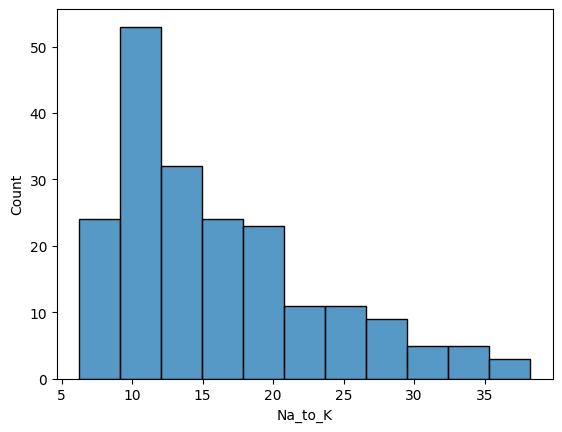

In [71]:
sns.histplot(df['Na_to_K']) # check the distribution of Na_to_K, is it normal?

Na_to_K feature have a slightly skewed distribution.

## Data Preprocessing

### Split Data

In [72]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Drug', axis=1) # drop the target variable
Y = df['Drug'] # set the target variable

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=69) # split the data into train and test set

### Data Cleaning
Data is already clean

### Feature Engineering

In [73]:
# Make a list of Numerical and Categortical Features

numeric_col = list()
object_col = list()

for col in x_train.columns : # loop through the columns in x_train
    if x_train[col].dtype == 'object' : # if the data type is object then append it to object_col
        object_col.append(col)
    else :
        numeric_col.append(col) # if the data type is not object then append it to numeric_col

In [33]:
object_col

['Sex', 'BP', 'Cholesterol']

In [34]:
numeric_col

['Age', 'Na_to_K']

#### Feature Scaling

Scaling is required because the data is not normaly distributed

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # instantiate the StandardScaler

# Train Data
x_train[numeric_col] = scaler.fit_transform(x_train[numeric_col])
# Test Data
x_test[numeric_col] = scaler.transform(x_test[numeric_col])


#### Feature Encoding

In [36]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) # instantiate the OrdinalEncoder

# Train Data
x_train[object_col] = enc.fit_transform(x_train[object_col])
# Test Data
x_test[object_col] = enc.transform(x_test[object_col])

## Model Training

Use A few different models and compare their results

In [38]:
from sklearn.metrics import classification_report

### SVM Model

In [37]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

#### Linear Kernel

In [40]:
svm_class_lr = SVC(kernel='linear')
svm_class_lr.fit(x_train, y_train)
svm_pred_lr = svm_class_lr.predict(x_test)

In [41]:
print(classification_report(y_test, svm_pred_lr))

              precision    recall  f1-score   support

       DrugY       0.96      0.86      0.91        28
       drugA       0.75      1.00      0.86         6
       drugB       0.75      0.60      0.67         5
       drugC       1.00      1.00      1.00         7
       drugX       0.88      1.00      0.93        14

    accuracy                           0.90        60
   macro avg       0.87      0.89      0.87        60
weighted avg       0.91      0.90      0.90        60



#### Polynomial Kernel

In [42]:
svm_class_poly = SVC(kernel='poly')
svm_class_poly.fit(x_train, y_train)
svm_pred_poly = svm_class_poly.predict(x_test)

In [43]:
print(classification_report(y_test, svm_pred_poly))

              precision    recall  f1-score   support

       DrugY       0.72      0.93      0.81        28
       drugA       0.75      0.50      0.60         6
       drugB       0.40      0.40      0.40         5
       drugC       0.00      0.00      0.00         7
       drugX       0.93      1.00      0.97        14

    accuracy                           0.75        60
   macro avg       0.56      0.57      0.56        60
weighted avg       0.66      0.75      0.70        60



C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result)

#### RBF Kernel

In [44]:
svm_class_rbf = SVC(kernel='rbf')
svm_class_rbf.fit(x_train, y_train)
svm_pred_rbf = svm_class_rbf.predict(x_test)

In [45]:
print(classification_report(y_test, svm_pred_rbf))

              precision    recall  f1-score   support

       DrugY       0.96      0.89      0.93        28
       drugA       0.86      1.00      0.92         6
       drugB       0.80      0.80      0.80         5
       drugC       1.00      0.43      0.60         7
       drugX       0.74      1.00      0.85        14

    accuracy                           0.87        60
   macro avg       0.87      0.82      0.82        60
weighted avg       0.89      0.87      0.86        60



### Ensemble Model

#### Bagging Classifier

In [46]:
from sklearn.ensemble import BaggingClassifier

##### Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

bag_dt = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=69), random_state=69)
bag_dt.fit(x_train, y_train)
bag_dt_pred = bag_dt.predict(x_test)

In [48]:
print(classification_report(y_test, bag_dt_pred))

              precision    recall  f1-score   support

       DrugY       0.97      1.00      0.98        28
       drugA       0.86      1.00      0.92         6
       drugB       1.00      0.80      0.89         5
       drugC       1.00      1.00      1.00         7
       drugX       1.00      0.93      0.96        14

    accuracy                           0.97        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.97      0.97      0.97        60



##### KNN

In [49]:
from sklearn.neighbors import KNeighborsClassifier

bag_knn = BaggingClassifier(estimator=KNeighborsClassifier(), random_state=69)
bag_knn.fit(x_train, y_train)
bag_knn_pred = bag_knn.predict(x_test)

In [50]:
print(classification_report(y_test, bag_knn_pred))

              precision    recall  f1-score   support

       DrugY       0.92      0.82      0.87        28
       drugA       0.86      1.00      0.92         6
       drugB       0.60      0.60      0.60         5
       drugC       1.00      0.57      0.73         7
       drugX       0.74      1.00      0.85        14

    accuracy                           0.83        60
   macro avg       0.82      0.80      0.79        60
weighted avg       0.85      0.83      0.83        60



##### Naive Bayes

In [51]:
from sklearn.naive_bayes import GaussianNB

bag_nb = BaggingClassifier(estimator=GaussianNB(), random_state=69)
bag_nb.fit(x_train, y_train)
bag_nb_pred = bag_nb.predict(x_test)

In [52]:
print(classification_report(y_test, bag_nb_pred))

              precision    recall  f1-score   support

       DrugY       0.95      0.71      0.82        28
       drugA       0.60      1.00      0.75         6
       drugB       0.83      1.00      0.91         5
       drugC       0.78      1.00      0.88         7
       drugX       0.93      0.93      0.93        14

    accuracy                           0.85        60
   macro avg       0.82      0.93      0.86        60
weighted avg       0.88      0.85      0.85        60



#### Boosting Classifier

##### AdaBoost

In [53]:
from sklearn.ensemble import AdaBoostClassifier

###### Decision Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier

ab_dt = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=69), random_state=69)
ab_dt.fit(x_train, y_train)
ab_dt_pred = ab_dt.predict(x_test)

In [55]:
print(classification_report(y_test, ab_dt_pred))

              precision    recall  f1-score   support

       DrugY       0.97      1.00      0.98        28
       drugA       0.86      1.00      0.92         6
       drugB       1.00      0.80      0.89         5
       drugC       1.00      1.00      1.00         7
       drugX       1.00      0.93      0.96        14

    accuracy                           0.97        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.97      0.97      0.97        60



###### Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression

ab_lr = AdaBoostClassifier(estimator=LogisticRegression(), random_state=69)
ab_lr.fit(x_train, y_train)
ab_lr_pred = ab_lr.predict(x_test)

In [60]:
print(classification_report(y_test, ab_lr_pred))

              precision    recall  f1-score   support

       DrugY       0.95      0.68      0.79        28
       drugA       0.60      1.00      0.75         6
       drugB       0.44      0.80      0.57         5
       drugC       0.36      0.57      0.44         7
       drugX       0.70      0.50      0.58        14

    accuracy                           0.67        60
   macro avg       0.61      0.71      0.63        60
weighted avg       0.75      0.67      0.68        60



###### Naive Bayes

In [61]:
from sklearn.naive_bayes import GaussianNB

ab_nb = AdaBoostClassifier(estimator=GaussianNB(), random_state=69)
ab_nb.fit(x_train, y_train)
ab_nb_pred = ab_nb.predict(x_test)

In [62]:
print(classification_report(y_test, ab_nb_pred))

              precision    recall  f1-score   support

       DrugY       0.56      1.00      0.72        28
       drugA       0.83      0.83      0.83         6
       drugB       0.75      0.60      0.67         5
       drugC       0.00      0.00      0.00         7
       drugX       0.00      0.00      0.00        14

    accuracy                           0.60        60
   macro avg       0.43      0.49      0.44        60
weighted avg       0.41      0.60      0.47        60



C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result)

#### Stacking Classifier

In [63]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('bag_dt', bag_dt), # bagging with decision tree based on the best bagging model
    ('ab_dt', ab_dt), # adaboost with decision tree based on the best adaboost model
    ('svc', svm_class_lr) # svm with linear kernel based on the best svm model
]

stack_class = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_class.fit(x_train,y_train)
stack_pred = stack_class.predict(x_test)

In [64]:
print(classification_report(y_test, stack_pred))

              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        28
       drugA       0.86      1.00      0.92         6
       drugB       1.00      0.80      0.89         5
       drugC       1.00      1.00      1.00         7
       drugX       1.00      1.00      1.00        14

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



## Result

From the Machine Learing Result we can conclude that the best model is stacking classifier with the following estimator:
- Bagging Classifier with Decision Tree
- AdaBoost with Decision Tree
- SVM with Linear Kernel

with the accuracy score of 0.98, and weighted precission of 0.98